<a href="https://colab.research.google.com/github/ArtemMakovskyy/data-analitics/blob/master/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **Data overview.** Розуміння даних та їх змісту.
- Завантаж датасет, розберись зі змістом колонок, зроби їх опис.
- Вияви ключові поля, що поєднують три таблиці.

- Завантаж датасет

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

DATA_PATH = "/content/drive/MyDrive/mateAcademy/Python/Exploratory_Data_Analysis/dataset"

def load_csv_file(path: str, file_name: str) -> pd.DataFrame:
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")

    if not os.path.exists(path):
        raise FileNotFoundError(f"Error: Path {path} not found. Check folder names.")

    file_path = os.path.join(path, file_name)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_name} not found in {path}.")

    df = pd.read_csv(file_path)
    print(f"File {file_name} loaded successfully. ({len(df)} rows)")
    return df

df_countries = load_csv_file(DATA_PATH, "countries.csv")
df_events = load_csv_file(DATA_PATH, "events.csv")
df_products  = load_csv_file(DATA_PATH, "products.csv")

- розберись зі змістом колонок

In [ ]:
def display_datasets_overview(datasets: dict) -> None:
    for name, df in datasets.items():
        print(f"\n\033[1m<--- {name} Overview --->\033[0m")
        df.info()
        print("\nFirst 3 rows:")
        display(df.head(3))
        print("Shape: ", df.shape)
        print("\033[1m<---End--->\033[0m")

datasets_to_review = {
    "Countries": df_countries,
    "Events": df_events,
    "Products": df_products
}

display_datasets_overview(datasets_to_review)


<--- Countries Overview --->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB

First 3 rows:


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe


Shape:  (249, 5)
<---End--->

<--- Events Overview --->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

First 3 rows:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54


Shape:  (1330, 10)
<---End--->

<--- Products Overview --->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes

First 3 rows:


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes


Shape:  (12, 2)
<---End--->


- зроби їх опис

In [ ]:
print("Countries columns:", df_countries.columns.tolist())
print("Events columns:", df_events.columns.tolist())
print("Products columns:", df_products.columns.tolist())

Countries columns: ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']
Events columns: ['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code', 'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost']
Products columns: ['id', 'item_type']


- Вияви ключові поля, що поєднують три таблиці

## countries
| Column       | Type    | Key |
|--------------|---------|-----|
| name         | object  |     |
| alpha-2      | object  |     |
| alpha-3      | object  | PK  |
| region       | object  |     |
| sub-region   | object  |     |
                ↑
                │ One
                │ to
                │ Many
## events
| Column         | Type     | Key |
|----------------|----------|-----|
| Order ID       | int64    |     |
| Order Date     | object   |     |
| Ship Date      | object   |     |
| Order Priority | object   |     |
| Country Code   | object   | FK ←── countries.alpha-3 |
| Product ID     | int64    | FK ←── products.id       |
| Sales Channel  | object   |     |
| Units Sold     | float64  |     |
| Unit Price     | float64  |     |
| Unit Cost      | float64  |     |
                │
                │ Many
                │ to
                │ One
                ↓
## products
| Column     | Type   | Key |
|------------|--------|-----|
| id         | int64  | PK  |
| item_type  | object |     |




2. **Data cleaning.** Робота із пропущеними даними, некоректними даними, аномаліями.
- a) Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.
- b) Заповни або видали пропущені значення, обґрунтувавши свою
думку.
- c) Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.
- d) Досліди дані на наявність дублікатів. Зверни увагу, що дублікати можуть траплятися через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, схожість літер у кирилиці/латиниці тощо. За потреби, зроби перетворення для усунення дублікатів.
- e) Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.

- a) Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.

In [ ]:
def display_missing_values(datasets: dict) -> None:
    for name, df in datasets.items():
        print(f"\n<--- {name} Missing Values --->")
        print(df.isna().sum())
        print("<---End--->")

display_missing_values(datasets_to_review)


<--- Countries Missing Values --->
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
<---End--->

<--- Events Missing Values --->
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
<---End--->

<--- Products Missing Values --->
id           0
item_type    0
dtype: int64
<---End--->


In [ ]:
def display_missing_percentage(datasets: dict) -> None:
    for name, df in datasets.items():
        print(f"\n<--- {name} Missing Percentage --->")
        print("rows: ", df.shape[0])
        print(df.isna().sum() / df.shape[0] * 100)
        print("<---End--->")

display_missing_percentage(datasets_to_review)


<--- Countries Missing Percentage --->
rows:  249
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64
<---End--->

<--- Events Missing Percentage --->
rows:  1330
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
<---End--->

<--- Products Missing Percentage --->
rows:  12
id           0.0
item_type    0.0
dtype: float64
<---End--->


In [ ]:
def display_missing_rows(datasets: dict, limit: int = 10) -> None:
    for name, df in datasets.items():
        print(f"\n<--- {name} Rows with Missing Values --->")
        missing_rows = df[df.isna().any(axis=1)]
        if missing_rows.empty:
            print("No missing values found.")
        else:
            print(missing_rows.head(limit).to_string())
        print("<--- End --->")

display_missing_rows(datasets_to_review)



<--- Countries Rows with Missing Values --->
           name alpha-2 alpha-3  region          sub-region
8    Antarctica      AQ     ATA     NaN                 NaN
153     Namibia     NaN     NAM  Africa  Sub-Saharan Africa
<--- End --->

<--- Events Rows with Missing Values --->
     Order ID Order Date  Ship Date Order Priority Country Code  Product ID Sales Channel  Units Sold  Unit Price  Unit Cost
2   101025998  7/18/2014  8/11/2014              M          NaN        7940        Online      4693.0      668.27     502.54
13  104548490   1/1/2014   1/5/2014              M          NaN        7331        Online      7076.0      255.28     159.42
26  117929494  1/24/2015   3/2/2015              H          NaN        4594       Offline      6813.0        9.33       6.92
29  118859469   6/2/2011   7/1/2011              L          NaN        8969       Offline      2013.0      152.58      97.44
43  126948583  5/24/2017   7/9/2017              C          NaN        7331        Online   

- b) Заповни або видали пропущені значення, обґрунтувавши свою думку.

Є пропуски у таблиці **countries**
Пропуски: ~0.4% у alpha-2, region, sub-region.

Причини:

* Antarctica не має регіону та субрегіону (геополітична особливість).

* Namibia — відсутній код alpha-2 (можливо, помилка у джерелі або неповні дані).

Рішення:  
У таблиці **df_countries** замінюємо пропуски в колонках `alpha-2`, region та sub-region на текст `"Unknown"`, щоб уникнути втрати даних. Це безпечно, оскільки об’єднання з таблицею **df_events** відбувається за заповненою колонкою `alpha-3`.

In [ ]:
# правильні назви колонок згідно з таблицею
df_countries['alpha-2'] = df_countries['alpha-2'].fillna('Unknown')
df_countries['region'] = df_countries['region'].fillna('Unknown')
df_countries['sub-region'] = df_countries['sub-region'].fillna('Unknown')

df_events['Country Code'] = df_events['Country Code'].fillna('Unknown')


Є пропуски у таблиці **events**
У колонці Country Code є ~6.2% пропусків (84 рядки).

У колонці Units Sold є лише 2 пропуски (~0.15%).

Рішення

* **Country Code (~6.2% пропусків**): пропуски замінено на "Unknown". Це дозволяє зберегти всі рядки у подальшому аналізі та бачити їх як окрему групу. Такий підхід дає прозорість у статистиці — ми не губимо дані, а явно показуємо, що країна не визначена.

* **Units Sold (0.15% пропусків**): заповнено медіаною. Через малу кількість пропусків це не вплине на результати та забезпечує коректність числових розрахунків.

In [ ]:
df_events["Units Sold"] = df_events["Units Sold"].fillna(df_events["Units Sold"].median())

In [ ]:
display_missing_values(datasets_to_review)


<--- Countries Missing Values --->
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64
<---End--->

<--- Events Missing Values --->
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64
<---End--->

<--- Products Missing Values --->
id           0
item_type    0
dtype: int64
<---End--->


- c) Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.

In [ ]:
df_events['Order Date'] = pd.to_datetime(df_events['Order Date'])
df_events['Ship Date'] = pd.to_datetime(df_events['Ship Date'])
df_events['Units Sold'] = df_events['Units Sold'].astype('int64')

- d) Досліди дані на наявність дублікатів. Зверни увагу, що дублікати можуть траплятися через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, схожість літер у кирилиці/латиниці тощо. За потреби, зроби перетворення для усунення дублікатів.

In [ ]:
def clean_string_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
    return df

def remove_exact_duplicates(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    initial_rows = len(df)
    df_cleaned = df.drop_duplicates()
    removed_count = initial_rows - len(df_cleaned)
    return df_cleaned, removed_count

def clean_and_check_duplicates(df: pd.DataFrame, name: str) -> pd.DataFrame:
    print(f"\n<--- {name} Duplicate Check --->")

    df_normalized = clean_string_columns(df)
    df_deduplicated, removed_dupes = remove_exact_duplicates(df_normalized)

    print(f"Видалено точних дублікатів: {removed_dupes}")
    return df_deduplicated

In [ ]:
df_countries['alpha-2'] = df_countries['alpha-2'].fillna('unknown')
df_countries['region'] = df_countries['region'].fillna('unknown')
df_countries['sub-region'] = df_countries['sub-region'].fillna('unknown')
df_events['Country Code'] = df_events['Country Code'].fillna('unknown')

In [ ]:
df_events = clean_and_check_duplicates(df_events, "events")
df_countries = clean_and_check_duplicates(df_countries, "countries")
df_products = clean_and_check_duplicates(df_products, "products")


<--- events Duplicate Check --->
Видалено точних дублікатів: 0

<--- countries Duplicate Check --->
Видалено точних дублікатів: 0

<--- products Duplicate Check --->
Видалено точних дублікатів: 0


* e) Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.

<--- Метрики для пошуку аномалій --->


,Units Sold,Unit Price,Unit Cost
count,1330.000000,1330.000000,1330.000000
mean,4952.216541,264.893541,187.246812
std,2903.012194,217.323460,176.158873
min,2.000000,9.330000,6.920000
25%,2360.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7458.750000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


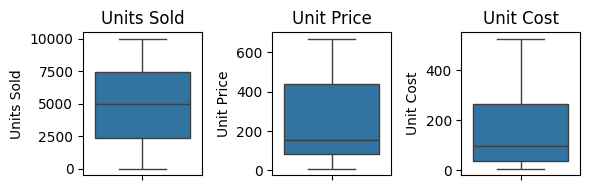

In [ ]:
print("<--- Метрики для пошуку аномалій --->")
display(df_events[['Units Sold', 'Unit Price', 'Unit Cost']].describe())

plt.figure(figsize=(6, 2))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_events['Units Sold'])
plt.title('Units Sold')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_events['Unit Price'])
plt.title('Unit Price')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_events['Unit Cost'])
plt.title('Unit Cost')

plt.tight_layout()
plt.show()

In [ ]:
# Selling to yourself at a loss
loss = df_events[df_events['Unit Cost'] > df_events['Unit Price']]
print(f"Unit Cost > Unit Price (продаж у збиток): {len(loss)} записів")

Unit Cost > Unit Price (продаж у збиток): 0 записів


In [ ]:
# Shipment date before order date
date_anomaly = df_events[df_events['Ship Date'] < df_events['Order Date']]
print(f"Ship Date < Order Date: {len(date_anomaly)} записів")

Ship Date < Order Date: 0 записів


Статистичних викидів у колонках Units Sold, Unit Price, Unit Cost не виявлено — всі значення лежать у логічному діапазоні та не виходять за межі вусів boxplot.
Логічних аномалій також не виявлено: відсутні випадки продажу у збиток (Unit Cost > Unit Price) та помилок у датах (Ship Date < Order Date).
**Єдина аномалія** — 82 записи (~6.2%) з відсутніми значеннями у колонці Country Code. Причина — помилка при зборі або імпорті даних.

3. **Data analysis and visualization**. Аналіз та візуалізація даних, знаходження цінних інсайтів.
- a) Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.
- b) Розпочни з ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо (придумай інші метрики).
- с) Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:
  *  категорій товарів;
  *  географії (країн, регіонів);
  *  каналів продажу (онлайн або офлайн).
- d) Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:
  *  категорій товарів;
  *  країн;
  *  регіонів.

- e) Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.
- f) Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.
- g) Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?

> 💡 Для знаходження дня тижня за датою скористайся методом `day_name()`.



- a) Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.

In [ ]:
# з’єднання трьох таблиць в один датафрейм
df = df_events.merge(
    df_countries,
    left_on='Country Code',
    right_on='alpha-3',
    how='left'
)

df = df.merge(
    df_products,
    left_on='Product ID',
    right_on='id',
    how='left'
)

In [ ]:
# Видали непотрібні для аналізу колонки
df = df.drop(columns=['alpha-3', 'id'])

In [ ]:
# зроби перейменування колонок
df = df.rename(columns={
    'name': 'Country',
    'sub_region': 'Sub Region',
    'item_type': 'Product Type',
    'alpha-2': 'Alpha2'
})
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

In [ ]:
# маска для рядків з unknown
mask_unknown = df['country_code'] == 'Unknown'

# заповнюємо по черзі всі географічні поля
df.loc[mask_unknown, 'country'] = df.loc[mask_unknown, 'country'].fillna('Unknown')
df.loc[mask_unknown, 'alpha2'] = df.loc[mask_unknown, 'alpha2'].fillna('Unknown')
df.loc[mask_unknown, 'region'] = df.loc[mask_unknown, 'region'].fillna('Unknown')
df.loc[mask_unknown, 'sub_region'] = df.loc[mask_unknown, 'sub_region'].fillna('Unknown')
df['country_code'] = df['country_code'].replace('unknown', 'Unknown')

# перевірка
print(df.loc[mask_unknown, ['country','alpha2','region','sub_region']].head())

Empty DataFrame
Columns: [country, alpha2, region, sub_region]
Index: []


- b) Розпочни з ключових метрик діяльності компанії:
    * загальна кількість замовлень,
    * загальний прибуток,
    * загальна кількість охоплених країн тощо
    * (придумай інші метрики).

In [ ]:
total_orders = df['order_id'].nunique()

df['profit'] = (df['unit_price'] - df['unit_cost']) * df['units_sold']
total_profit = df['profit'].sum()

total_countries = df['country'].nunique()
total_units = df['units_sold'].sum()
avg_margin = ((df['unit_price'] - df['unit_cost']) / df['unit_price']).mean().round(2) * 100
unique_products = df['product_id'].nunique()
sales_channel_dist = df['sales_channel'].value_counts(normalize=True)

print("1) Загальна кількість замовлень:", total_orders)
print("2) Загальний прибуток:", total_profit)
print("3) Кількість охоплених країн:", total_countries)
print("4) Загальна кількість проданих одиниць:", total_units)
print(f"5) Середня маржинальність: {avg_margin}%")
print("6) Кількість унікальних продуктів:", unique_products)
print("7) Розподіл каналів продажу:\n", sales_channel_dist)

1) Загальна кількість замовлень: 1330
2) Загальний прибуток: 501842633.12
3) Кількість охоплених країн: 45
4) Загальна кількість проданих одиниць: 6586448
5) Середня маржинальність: 34.0%
6) Кількість унікальних продуктів: 12
7) Розподіл каналів продажу:
 sales_channel
offline    0.501504
online     0.498496
Name: proportion, dtype: float64


- с) Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:

категорій товарів;
географії (країн, регіонів);
каналів продажу (онлайн або офлайн).

In [ ]:
# Обчислюєм та додаєм колонки з доходом, витратами та прибутком (був вже доданий) по кожному замовленню
df['revenue'] = df['units_sold'] * df['unit_price']
df['cost'] = df['units_sold'] * df['unit_cost']

In [ ]:
# Сортуем по даті замовлень
df = df.sort_values(
    by=['order_date', 'ship_date', 'profit'],
    ascending=[True, True, False]
)

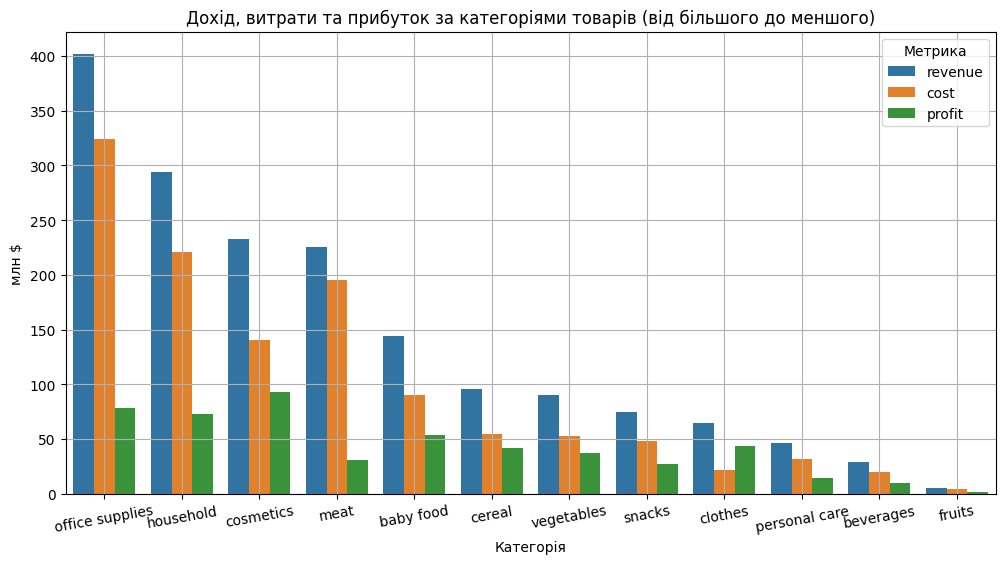

In [ ]:
# Дохід, витрати та прибуток за категоріями товарів
by_category = df.groupby('product_type')[['revenue','cost','profit']].sum().reset_index()

by_category_sorted = by_category.sort_values('revenue', ascending=False)

by_category_melted = by_category_sorted.melt(
    id_vars='product_type',
    value_vars=['revenue','cost','profit'],
    var_name='metric',
    value_name='value'
)

by_category_melted['value'] = by_category_melted['value'] / 1_000_000

order = by_category_sorted['product_type'].tolist()

plt.figure(figsize=(12,6))
sns.barplot(data=by_category_melted, x='product_type', y='value', hue='metric', order=order)
plt.title('Дохід, витрати та прибуток за категоріями товарів (від більшого до меншого)')
plt.xlabel('Категорія')
plt.ylabel('млн $')
plt.legend(title='Метрика')
plt.xticks(rotation=10)
plt.grid(True)
plt.show()


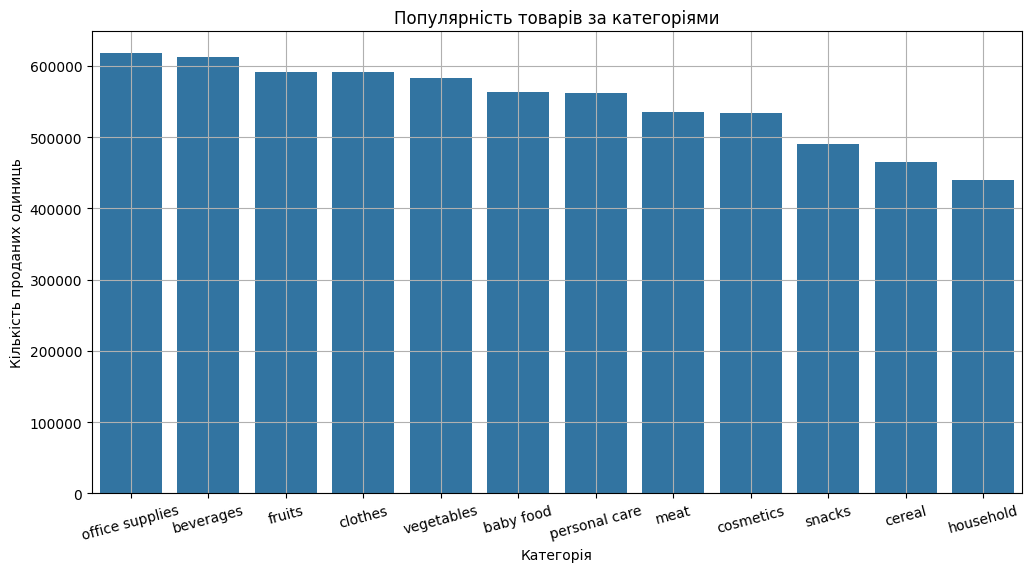

In [ ]:
# Популярність товарів (кількість проданих одиниць)
pop_category = df.groupby('product_type')['units_sold'].sum().reset_index().sort_values('units_sold', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=pop_category, x='product_type', y='units_sold')
plt.title('Популярність товарів за категоріями')
plt.xlabel('Категорія')
plt.ylabel('Кількість проданих одиниць')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

In [ ]:
# доходи, витрати, прибутки (географії країни)
by_country = df.groupby('country')[['revenue','cost','profit']].sum().reset_index()

# сортуємо, але не відбираємо топ — беремо всі країни
by_country = by_country.sort_values('profit', ascending=False)

# перетворюємо у формат long для побудови графіка
by_country = by_country.melt(
    id_vars='country',
    value_vars=['revenue','cost','profit'],
    var_name='metric',
    value_name='value'
)

# переводимо у мільйони
by_country['value'] = by_country['value'] / 1_000_000

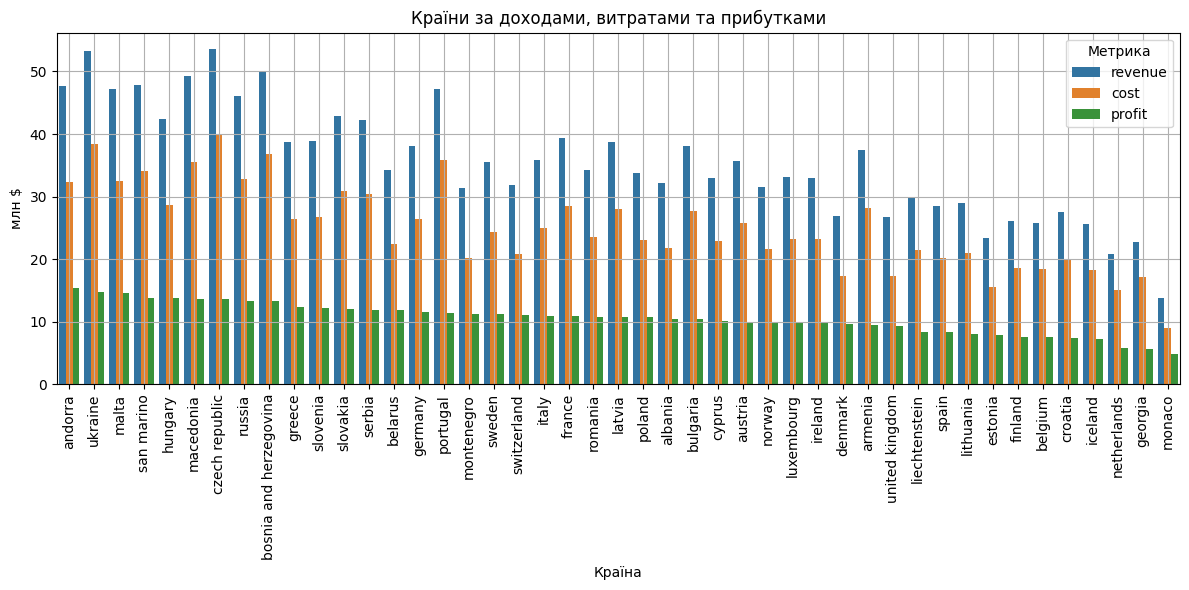

In [ ]:
# будуємо графік
plt.figure(figsize=(12,6))
sns.barplot(data=by_country, x='country', y='value', hue='metric')
plt.title('Країни за доходами, витратами та прибутками')
plt.xlabel('Країна')
plt.ylabel('млн $')
plt.legend(title='Метрика')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
by_region = df.groupby('region')[['revenue', 'cost', 'profit']].sum().reset_index()

# Перетворюємо у long format прямо в тій же змінній
by_region = by_region.melt(
    id_vars='region',
    value_vars=['revenue', 'cost', 'profit'],
    var_name='metric',
    value_name='value'
)

# Ділимо на мільйони
by_region['value'] = by_region['value'] / 1_000_000

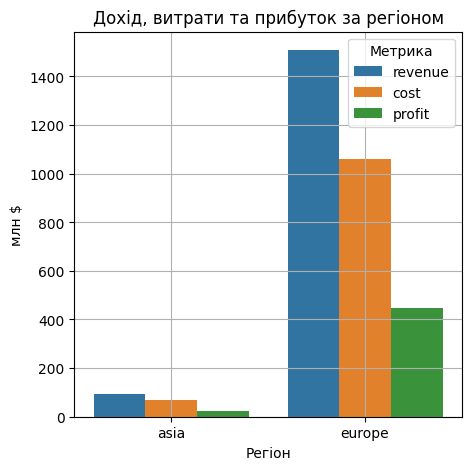

In [ ]:
# Візуалізація дохіду, витрат та прибутоку за регіоном
plt.figure(figsize=(5, 5))
sns.barplot(data=by_region, x='region', y='value', hue='metric')
plt.title('Дохід, витрати та прибуток за регіоном')
plt.xlabel('Регіон')
plt.ylabel('млн $')
plt.legend(title='Метрика')
plt.grid(True)
plt.show()

Регіони — у датасеті лише europe, asia та Unknown. Дані охоплюють лише ці регіони, що є обмеженням датасету.

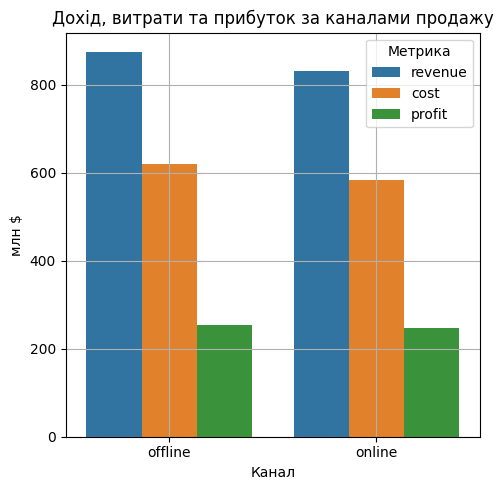

In [ ]:
# Канали продажу (online vs offline)
by_channel = df.groupby('sales_channel')[['revenue','cost','profit']].sum().reset_index()

by_channel = by_channel.melt(id_vars='sales_channel', value_vars=['revenue','cost','profit'],
                             var_name='metric', value_name='value')
by_channel['value'] = by_channel['value'] / 1_000_000

plt.figure(figsize=(5,5))
sns.barplot(data=by_channel, x='sales_channel', y='value', hue='metric')
plt.title('Дохід, витрати та прибуток за каналами продажу')
plt.xlabel('Канал')
plt.ylabel('млн $')
plt.legend(title='Метрика')
plt.tight_layout()
plt.grid(True)
plt.show()

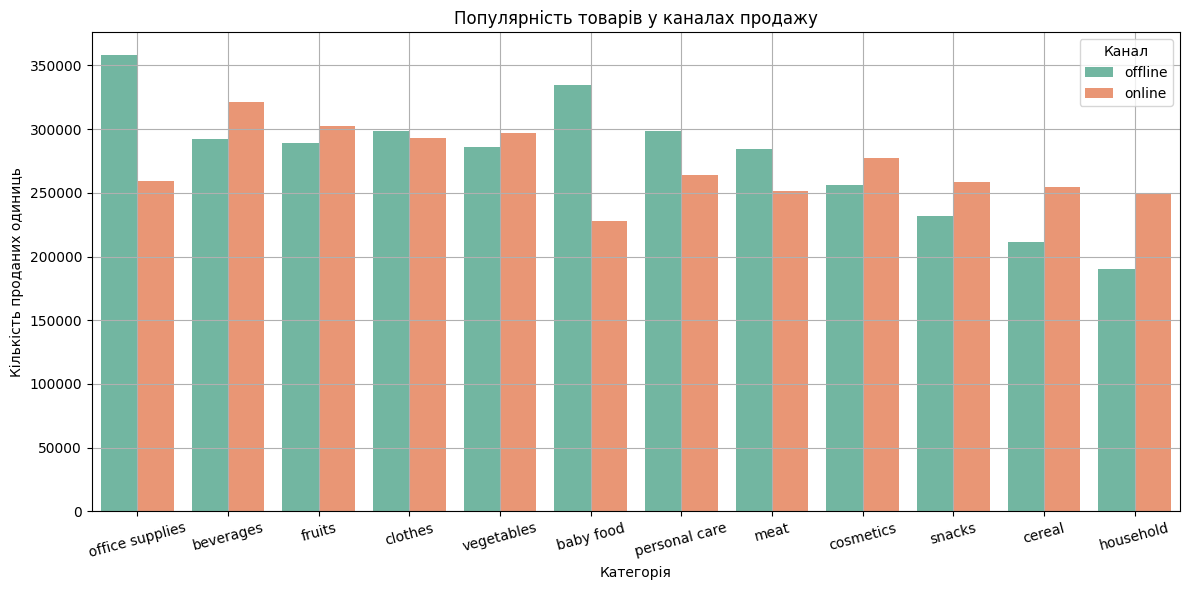

In [ ]:
# Популярність товарів у каналах
pop_channel = df.groupby(['sales_channel','product_type'])['units_sold'].sum().reset_index()
category_order = pop_channel.groupby('product_type')['units_sold'].sum().sort_values(ascending=False).index

plt.figure(figsize=(12,6))
sns.barplot(data=pop_channel, x='product_type', y='units_sold', hue='sales_channel', palette='Set2', order=category_order)
plt.title('Популярність товарів у каналах продажу')
plt.xlabel('Категорія')
plt.ylabel('Кількість проданих одиниць')
plt.xticks(rotation=15)
plt.legend(title='Канал')
plt.tight_layout()
plt.grid(True)
plt.show()

- d) Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:
  *  категорій товарів;
  *  країн;
  *  регіонів.

In [ ]:
# створюємо колонку shipping_delay
df['shipping_delay'] = (df['ship_date'] - df['order_date']).dt.days

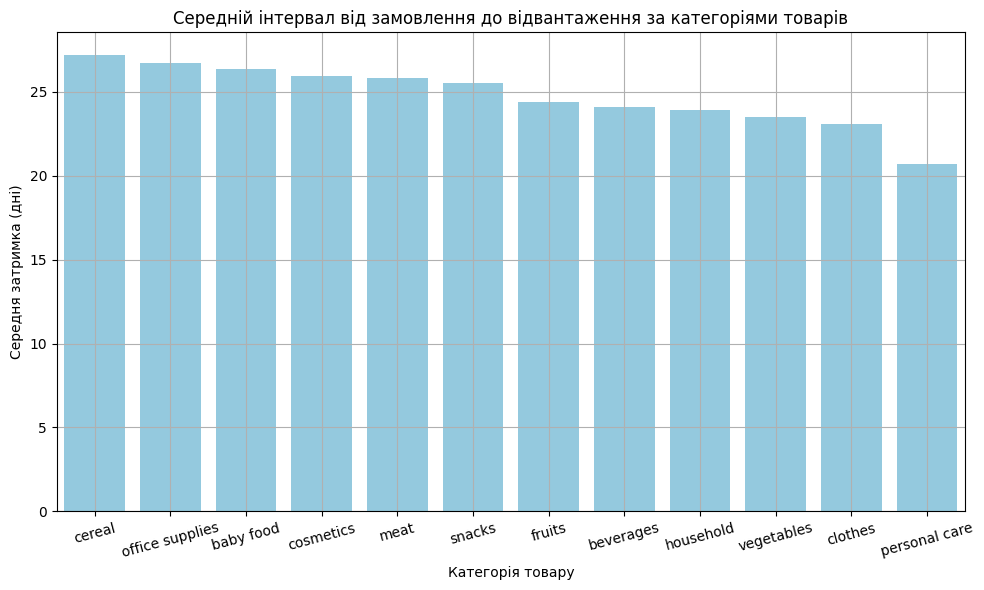

In [ ]:
# інтервал часу між замовленням та його відвантаженням в розрізі категорії товарів
by_category_delay = df.groupby('product_type')['shipping_delay'].mean().reset_index()
by_category_delay = by_category_delay.sort_values(['shipping_delay'], ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=by_category_delay, x='product_type', y='shipping_delay', color='skyblue')
plt.title('Середній інтервал від замовлення до відвантаження за категоріями товарів')
plt.xlabel('Категорія товару')
plt.ylabel('Середня затримка (дні)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid(True)
plt.show()

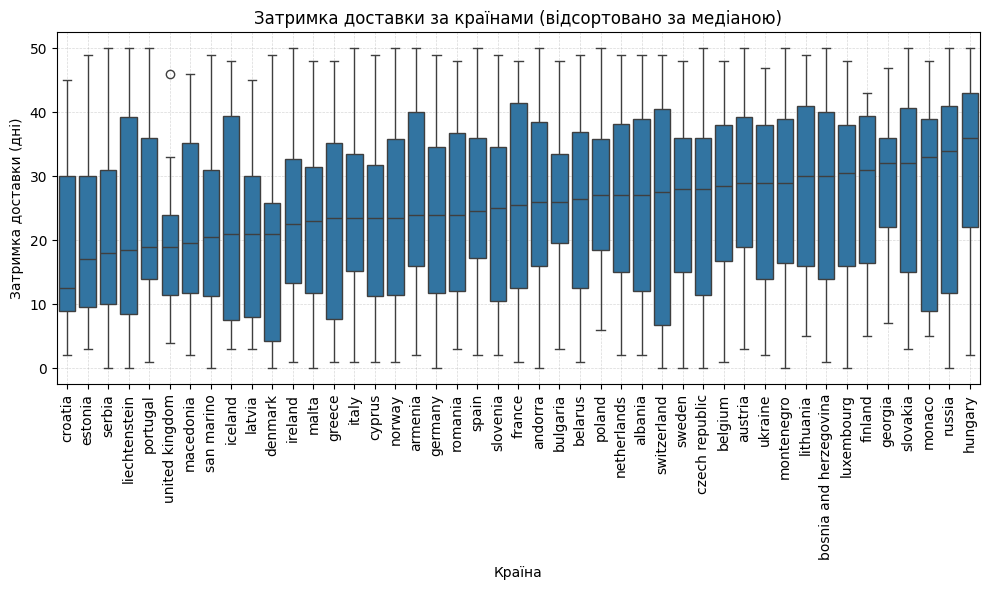

In [ ]:
# Інтервал часу між замовленням та його відвантаженням у розрізі країн
median_order = (df.groupby("country")["shipping_delay"].median().sort_values().index)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="country", y="shipping_delay", order=median_order)

plt.title("Затримка доставки за країнами (відсортовано за медіаною)")
plt.xlabel("Країна")
plt.ylabel("Затримка доставки (дні)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)
plt.show()

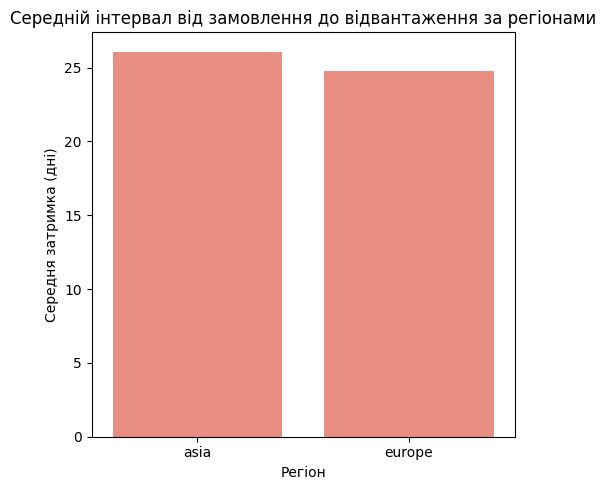

In [ ]:
# інтервал часу між замовленням та його відвантаженням в розрізі категорії регіону
by_region_delay = df.groupby('region')['shipping_delay'].mean().reset_index()

plt.figure(figsize=(5,5))
sns.barplot(data=by_region_delay, x='region', y='shipping_delay', color='salmon')
plt.title('Середній інтервал від замовлення до відвантаження за регіонами')
plt.xlabel('Регіон')
plt.ylabel('Середня затримка (дні)')
plt.tight_layout()
plt.show()

- e) Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.

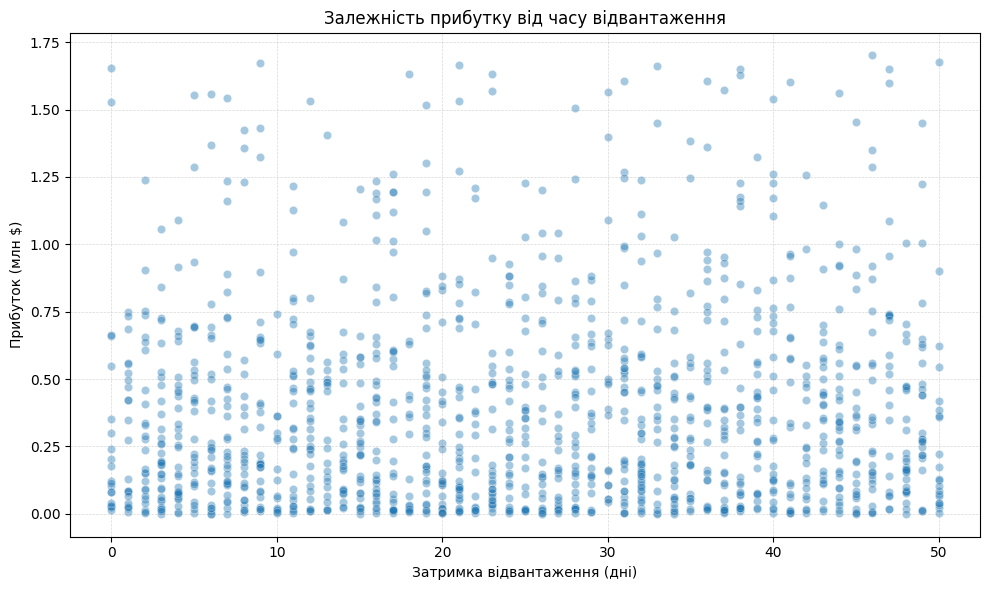

In [ ]:
# нормалізуємо прибуток у млн $
df['profit_mln'] = df['profit'] / 1_000_000

# Scatter plot: прибуток vs затримка
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='shipping_delay', y='profit_mln', alpha=0.4)
plt.title('Залежність прибутку від часу відвантаження')
plt.xlabel('Затримка відвантаження (дні)')
plt.ylabel('Прибуток (млн $)')
plt.tight_layout()
plt.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.3)
plt.show()

Висновок: точки розкидані хаотично, немає чіткої лінійної залежності. Це означає, що прибуток напряму не залежить від кількості днів затримки.

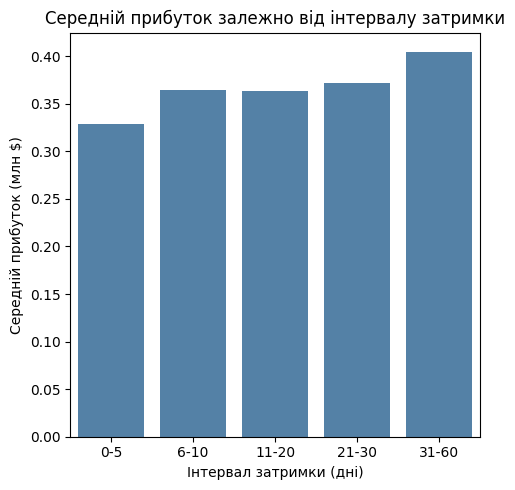

In [ ]:
# Середній прибуток по інтервалах затримки
delay_bins = pd.cut(df['shipping_delay'], bins=[0,5,10,20,30,60], labels=['0-5','6-10','11-20','21-30','31-60'])
by_delay = df.groupby(delay_bins, observed=True)['profit_mln'].mean().reset_index()

plt.figure(figsize=(5,5))
sns.barplot(data=by_delay, x='shipping_delay', y='profit_mln', color='steelblue')
plt.title('Середній прибуток залежно від інтервалу затримки')
plt.xlabel('Інтервал затримки (дні)')
plt.ylabel('Середній прибуток (млн $)')
plt.tight_layout()
plt.show()

Середній прибуток у групах із затримкою 6–30 днів залишається стабільним, а помітне зростання видно лише при дуже довгих затримках (31–60 днів). Це свідчить, що **прибуток напряму не залежить від часу відвантаження, але великі замовлення з довшими термінами можуть приносити більше доходу.**

- f) Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.

In [ ]:
# Формуємо групи категорій
# Рахуємо сумарний прибуток по кожній категорії
category_total = df.groupby('product_type')['profit_mln'].sum().sort_values(ascending=False)

top4 = category_total.index[:4]
mid4 = category_total.index[4:8]
bottom4 = category_total.index[-4:]

In [ ]:
# Метод для групування по кварталах
def group_profit_by_quarter(df, categories):
    # 1. Фільтрація по категоріях
    temp = df[df['product_type'].isin(categories)]

    # 2. Перетворення дати у квартал
    quarters = temp['order_date'].dt.to_period('Q')

    # 3. Створюємо окремі колонки для року та кварталу
    years = quarters.dt.year
    qnums = quarters.dt.quarter

    # 4. Формуємо текстове представлення "YYYY Qn"
    quarter_labels = years.astype(str) + " Q" + qnums.astype(str)

    # 5. Групування по кварталах та категоріях
    grouped = temp.groupby([quarter_labels, 'product_type'])['profit_mln'].sum()

    # 6. Повертаємо результат у DataFrame
    return grouped.reset_index()

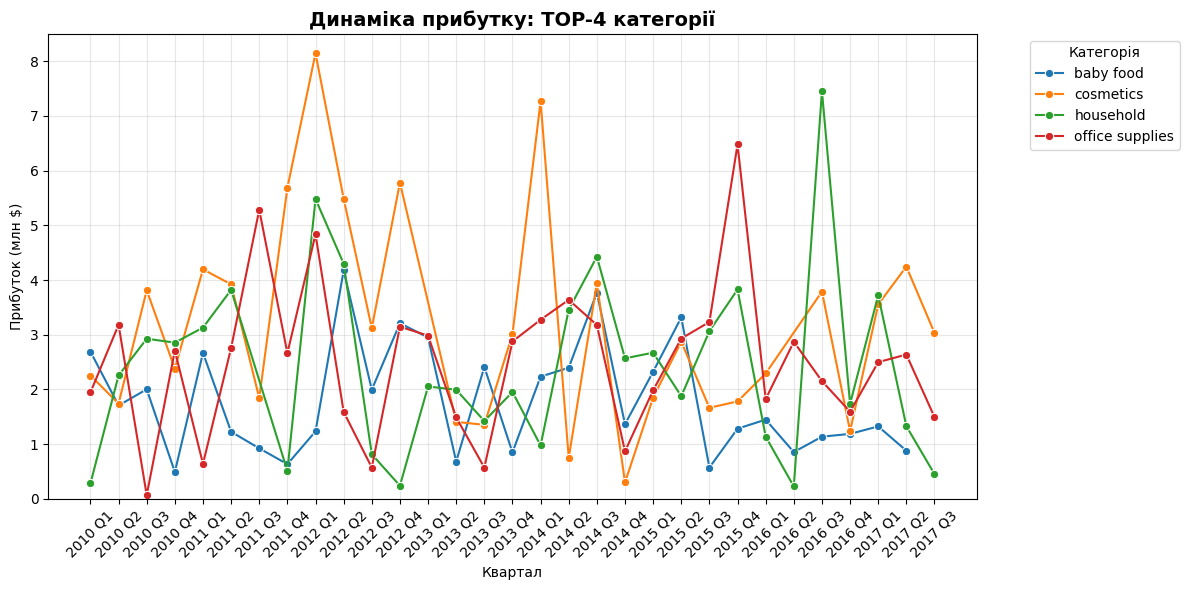

In [ ]:
# Динаміка продажів у часі у розрізі товарів
# TOP-4 категорії
by_category_profit = group_profit_by_quarter(df, top4)

plt.figure(figsize=(12,6))
sns.lineplot(data=by_category_profit, x='order_date', y='profit_mln', hue='product_type', marker='o')
plt.title("Динаміка прибутку: TOP-4 категорії", fontsize=14, fontweight='bold')
plt.xlabel("Квартал")
plt.ylabel("Прибуток (млн $)")
plt.ylim(0, 8.5)
plt.legend(title="Категорія", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

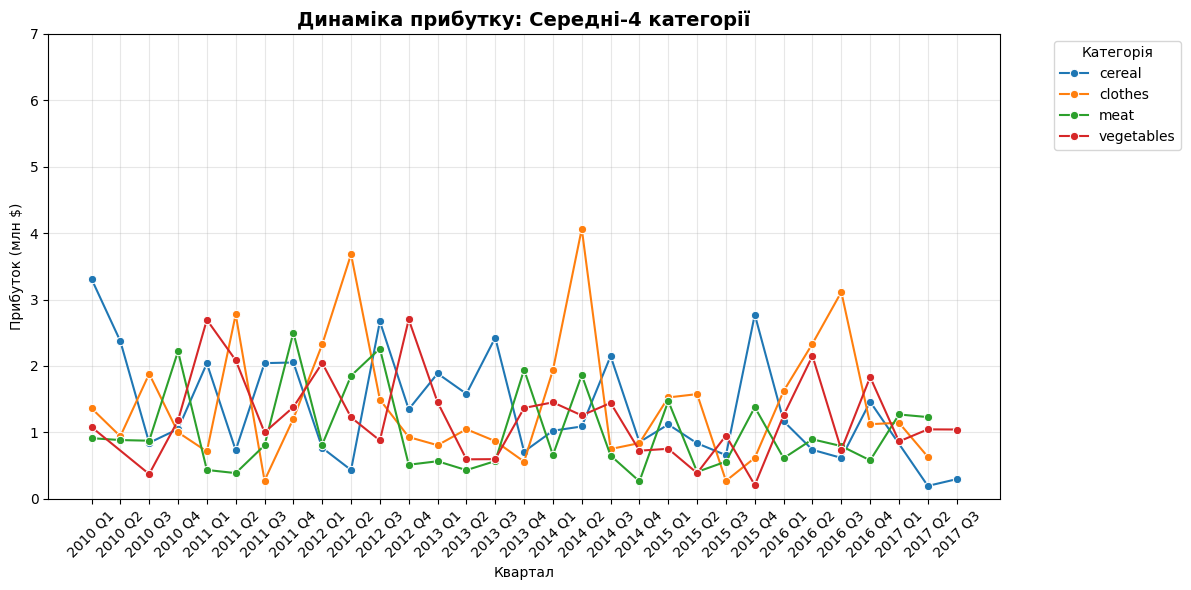

In [ ]:
# Динаміка продажів у часі у розрізі отварів
# Середні-4 категорії
by_category_profit = group_profit_by_quarter(df, mid4)


plt.figure(figsize=(12,6))
sns.lineplot(data=by_category_profit, x='order_date', y='profit_mln', hue='product_type', marker='o')
plt.title("Динаміка прибутку: Середні-4 категорії", fontsize=14, fontweight='bold')
plt.xlabel("Квартал")
plt.ylabel("Прибуток (млн $)")
plt.ylim(0, 7)
plt.legend(title="Категорія", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

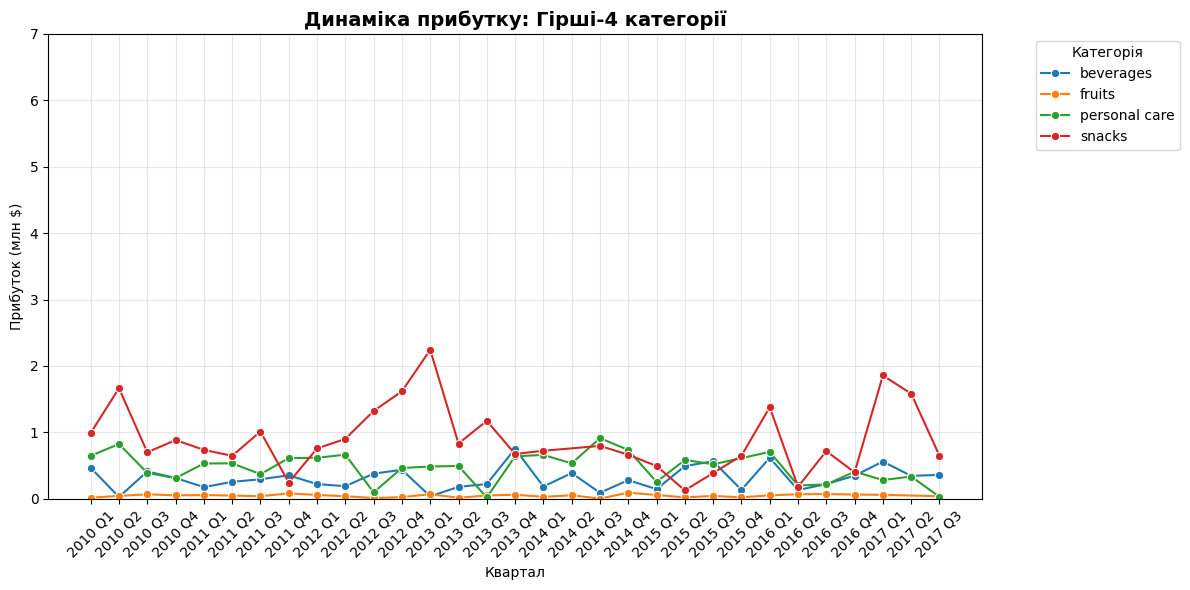

In [ ]:
# Динаміка продажів у часі у розрізі отварів
# Гірші-4 категорії
by_category_profit = group_profit_by_quarter(df, bottom4)

plt.figure(figsize=(12,6))
sns.lineplot(data=by_category_profit, x='order_date', y='profit_mln', hue='product_type', marker='o')
plt.title("Динаміка прибутку: Гірші-4 категорії", fontsize=14, fontweight='bold')
plt.xlabel("Квартал")
plt.ylabel("Прибуток (млн $)")
plt.ylim(0, 7)
plt.legend(title="Категорія", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Перетворюємо дату у квартал
quarters = df['order_date'].dt.to_period('Q')

# 2. Створюємо окремі колонки для року та кварталу
years = quarters.dt.year
qnums = quarters.dt.quarter

# 3. Формуємо текстове представлення "YYYY Qn"
quarter_labels = years.astype(str) + " Q" + qnums.astype(str)

# 4. Групуємо по кварталах та регіонах
grouped = df.groupby([quarter_labels, 'region'])['profit_mln'].sum()

# 5. Перетворюємо результат у DataFrame
by_region_profit = grouped.reset_index()

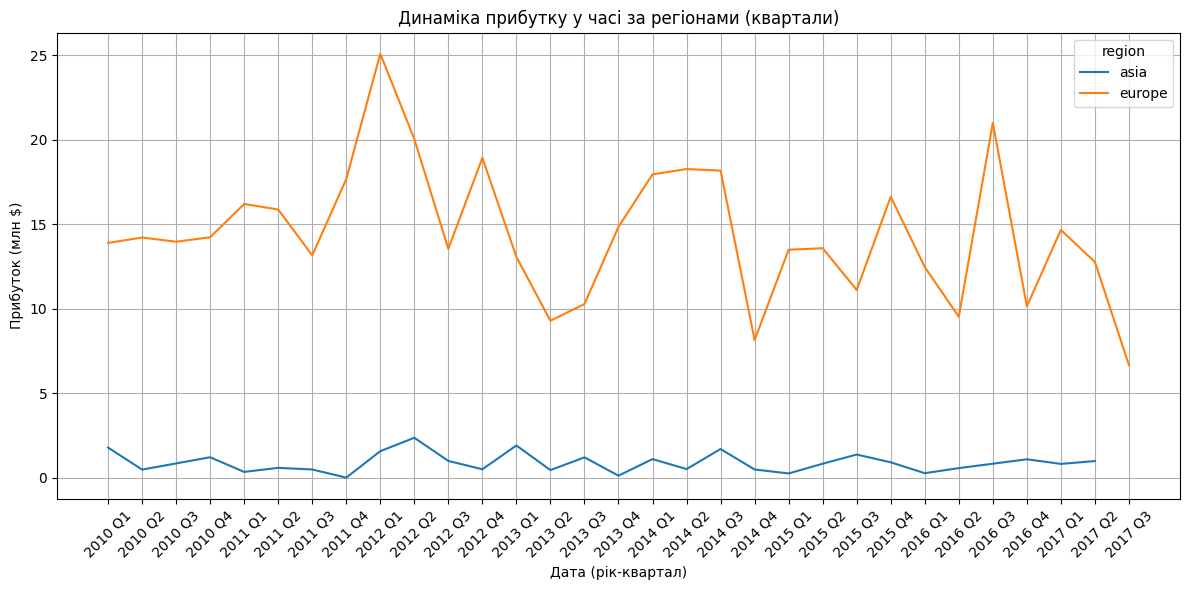

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=by_region_profit, x='order_date', y='profit_mln', hue='region')
plt.title('Динаміка прибутку у часі за регіонами (квартали)')
plt.xlabel('Дата (рік-квартал)')
plt.ylabel('Прибуток (млн $)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

- g) Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?

> 💡 Для знаходження дня тижня за датою скористайся методом `day_name()`.


In [ ]:
# додаємо колонку з днем тижня
df['day_of_week'] = df['order_date'].dt.day_name()
# масив днів тижня
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

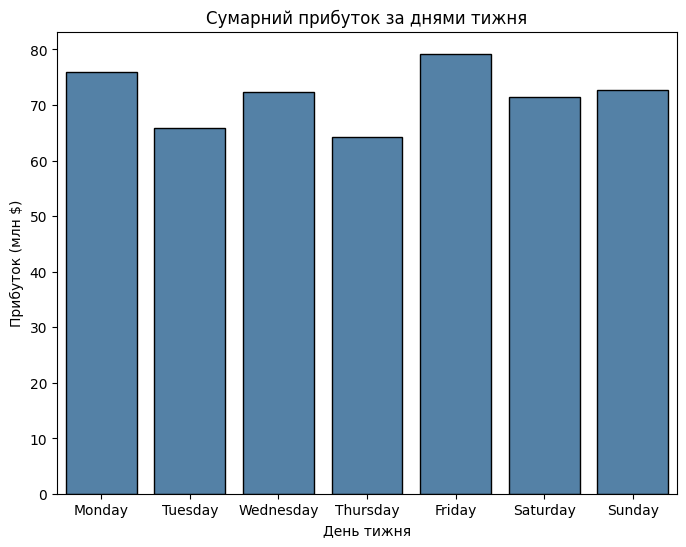

In [ ]:
# Прибуток за днями тижня (загалом) ---
by_day = df.groupby('day_of_week')['profit_mln'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=by_day, x='day_of_week', y='profit_mln', color='steelblue', edgecolor="black", order=days_order)
plt.title('Сумарний прибуток за днями тижня')
plt.xlabel('День тижня')
plt.ylabel('Прибуток (млн $)')
plt.show()

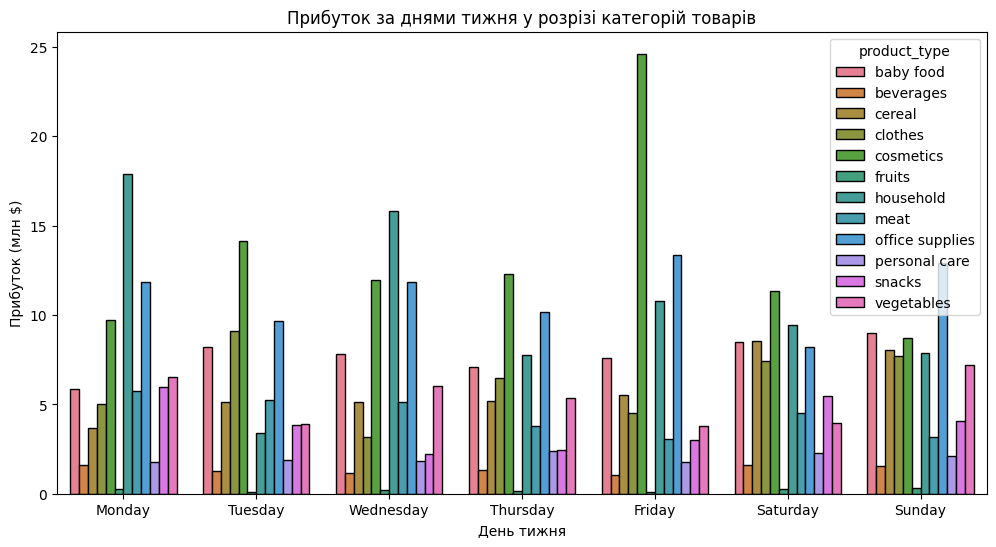

In [ ]:
# Прибуток за днями тижня у розрізі категорій
by_day_category = df.groupby(['day_of_week','product_type'])['profit_mln'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=by_day_category, x='day_of_week', y='profit_mln', edgecolor="black", hue='product_type', order=days_order)
plt.title('Прибуток за днями тижня у розрізі категорій товарів')
plt.xlabel('День тижня')
plt.ylabel('Прибуток (млн $)')
plt.show()

На графіку найбільш виражену “сезонність” (тобто нерівномірний попит) показують:

**cosmetics**— сильний пік у п’ятницю
**fruits / household** — помітні піки в окремі дні (особливо початок і кінець тижня)

Натомість такі категорії як baby_food, beverages, snacks, vegetables виглядають більш стабільними, без різких стрибків, тобто менш сезонними.

In [ ]:
# функція для визначення сезону за місяцем
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

In [ ]:
# додаємо колонку "season"
df['season'] = df['order_date'].dt.month.apply(get_season)

In [ ]:
# порядок сезонів
season_order = ['Winter','Spring','Summer','Autumn']

In [ ]:
# групування прибутку по сезонах та категоріях
by_season_category = df.groupby(['season','product_type'])['profit_mln'].sum().reset_index()

In [ ]:
# писок категорій товарів
categories = df['product_type'].unique()

In [ ]:
# Палітра кольорів (однакові кольори для кожного товару)
palette = dict(zip(categories, sns.color_palette("tab20", len(categories))))

In [ ]:
# Групування кількості товарів по сезонах та категоріях
by_season_category_units = df.groupby(['season','product_type'])['units_sold'].sum().reset_index()

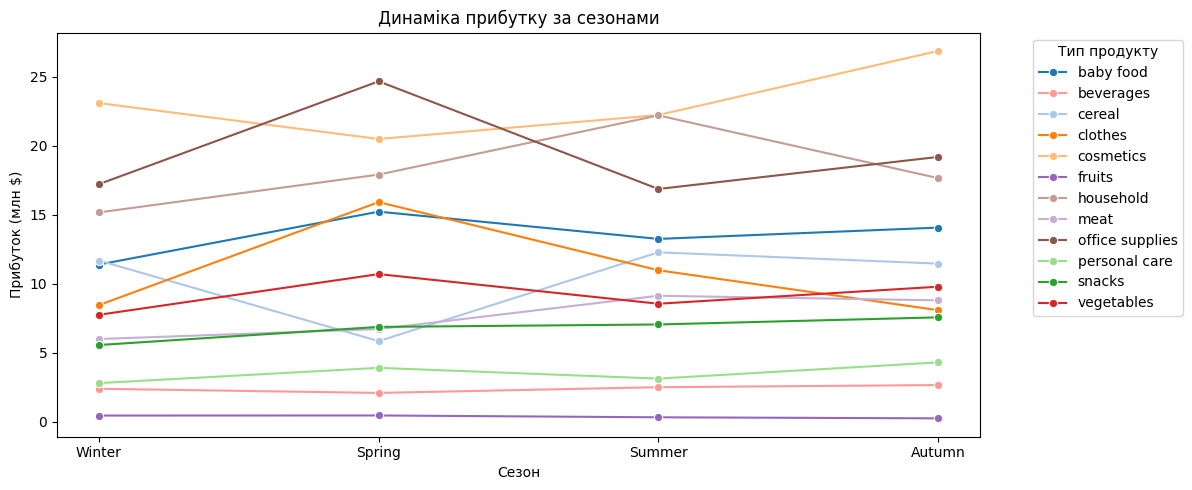

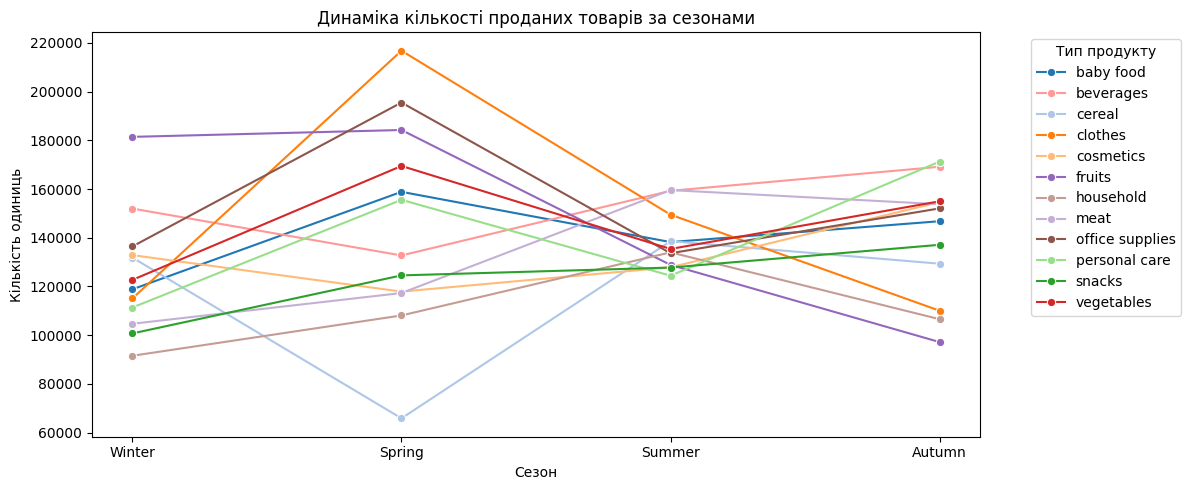

In [ ]:
# Графік прибутку
plt.figure(figsize=(10,5))
sns.lineplot(data=by_season_category, x='season', y='profit_mln',
             hue='product_type', marker='o', palette=palette, sort=False)
plt.title('Динаміка прибутку за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Прибуток (млн $)')
plt.xticks(ticks=range(len(season_order)), labels=season_order)
plt.tight_layout()
plt.legend(title="Тип продукту", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Графік кількості товарів
plt.figure(figsize=(10,5))
sns.lineplot(data=by_season_category_units, x='season', y='units_sold',
             hue='product_type', marker='o', palette=palette, sort=False)
plt.title('Динаміка кількості проданих товарів за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Кількість одиниць')
plt.xticks(ticks=range(len(season_order)), labels=season_order)
plt.tight_layout()
plt.legend(title="Тип продукту", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Висновок**

**Прибуток**: Лідери — cosmetics (зростає до ~27 млн $ восени) та Clothes (пік навесні ~25 млн $, потім спад). Решта категорій стабільні й помірні.
Сезонні товари:

* Clothes — яскравий весняний пік (продажі та прибуток)
* Office supplies — аналогічно, весняний сплеск
* Vegetables — активніші навесні/влітку

Стабільні весь рік: baby food, beverages, personal care, meat.

4. **Reporting**. Склади детальний звіт у файлі Google Colab із кодом, графіками та поясненнями. Зроби висновки з точки зору бізнес-логіки.

# Звіт з аналізу продажів — Retail Dataset
> **Data Analytics Project** | Python, Pandas, Seaborn, Matplotlib

---

## Загальний огляд

Проєкт присвячений дослідженню роздрібних продажів компанії на основі трьох таблиць: замовлення (`events`), країни (`countries`) та товари (`products`). Датасет охоплює **1 330 замовлень** у **46 країнах** із **12 категоріями товарів** за період 2010–2017 років.

Загальний прибуток компанії склав **~502 млн $** при середній маржинальності **34%**. Продажі розподілені майже рівномірно між онлайн та офлайн каналами (≈50/50). Основні ринки зосереджені в **Європі** та **Азії**.

Аналіз виявив ключові закономірності у сезонності товарів, географічній концентрації прибутку та відсутності впливу затримки відвантаження на фінансові результати.

---

## 1. Аналіз за категоріями товарів

### Висновки
- **Office supplies** та **Household** генерують найбільший дохід і прибуток серед усіх категорій.

- **Cosmetics** демонструє стабільне зростання прибутку впродовж року з піком восени (~27 млн $).

- **Clothes** — найбільш волатильна категорія: різкий весняний пік (~25 млн $) із подальшим спадом.

- **Fruits** — найменш прибуткова категорія з мінімальним доходом. **Meat** має високий дохід (~230 млн $), але відносно низький прибуток (~30 млн $) через високу собівартість.

### Бізнес-рекомендації
- Збільшити інвестиції в **Cosmetics** — стабільний попит і висока маржинальність роблять цю категорію найнадійнішою.
- Для **Clothes** планувати **сезонні акції та поповнення запасів у лютому-березні** до весняного піку.
- Переглянути стратегію для **Fruits та Meat** — або підвищити маржу, або скоротити асортимент на користь прибутковіших категорій.

---

## 2. Географічний аналіз

### Висновки
- **Європа** — основний ринок компанії, генерує переважну більшість прибутку.
- **Азія** присутня, але значно поступається Європі за обсягами.
- **~6.2% замовлень** (82 записи) не мають прив'язки до країни — це обмеження датасету.
- Топ-країни за прибутком:  **Andora, Ukraine, Malta, San Marino,  Hungary**.

### Бізнес-рекомендації
- Фокусуватись на **розвитку присутності в топ-країнах Європи** — там найвища концентрація прибутку.
- Розглянути **розширення в Азію** як стратегічний напрямок зростання — ринок недооцінений.
- Вирішити проблему з **невідомими країнами** на рівні збору даних — 6% "сліпих" замовлень ускладнюють географічний аналіз.

---

## 3. Аналіз каналів продажу

### Висновки
- Offline: **50.15%** замовлень, Online: **49.85%** — канали практично рівні.
- Дохід та прибуток також розподілені рівномірно між каналами.
- Більшість категорій товарів не мають суттєвого перекосу між каналами.

### Бізнес-рекомендації
- **Не концентрувати ресурси лише на одному каналі** — обидва однаково ефективні.
- Проаналізувати **собівартість обслуговування** кожного каналу — за однакового доходу офлайн може коштувати дорожче.
---

## 4. Аналіз затримки відвантаження

### Висновки
- Середня затримка по всіх категоріях та країнах — **20–27 днів**.
- Scatter plot та групування по інтервалах показують: **чіткої залежності між затримкою та прибутком немає**.
- Незначне зростання прибутку при затримках 31–60 днів пояснюється великими замовленнями, а не самою затримкою.

### Бізнес-рекомендації
- **Логістична оптимізація не є пріоритетом** з точки зору прибутку — інвестиції краще спрямувати в маркетинг або асортимент.
- Однак затримка впливає на **задоволеність клієнтів** — варто моніторити як окрему метрику якості сервісу.

---

## 5. Сезонний аналіз

### Висновки
| Категорія | Характер | Пік |
|---|---|---|
| **Clothes** | Яскраво сезонний | Весна |
| **Office supplies** | Сезонний | Весна |
| **Vegetables** | Помірно сезонний | Весна–Літо |
| **Cosmetics** | Зростаючий тренд | Осінь |
| **Baby food, Beverages, Meat** | Стабільні | — |

### Бізнес-рекомендації
- Для сезонних товарів (**Clothes, Office supplies**) впроваджувати **динамічне ціноутворення** — підвищувати ціни в пік, знижувати поза сезоном.
- Планувати **маркетингові кампанії для Cosmetics восени** — там найвищий прибуток.
- Стабільні категорії використовувати як **базовий дохід** для покриття постійних витрат.

---

## Обмеження аналізу

- Датасет охоплює лише **Європу та Азію** — глобальних висновків робити не можна.
- **6.2% замовлень** без прив'язки до країни — частина географічного аналізу неповна.
- Відсутні дані про **повернення товарів, витрати на маркетинг та логістику** — реальна маржинальність може відрізнятись.

---

## Загальні висновки

**Топ-3 інсайти:**
1. **Cosmetics** — найстабільніша та найперспективніша категорія для інвестицій.
2. **Clothes** — потребує сезонного планування, інакше компанія втрачає прибуток поза піком.
3. **Затримка відвантаження не впливає на прибуток** — логістика не є вузьким місцем бізнесу.

**Топ-3 рекомендації:**
1. Збільшити частку **Cosmetics** в асортименті та маркетингу.
2. Впровадити **сезонне планування запасів** для Clothes та Office supplies.
3. Вирішити проблему **збору даних про країни** — 6% невідомих замовлень є сліпою зоною.
